In [2]:
import numpy as np
import xarray as xr
import os
from matplotlib import pyplot as plt
from tqdm import tqdm
from wavediffusion.waveana import assemble 
import cartopy.crs as ccrs
from wavediffusion.waveana import add_lat_lon

%load_ext autoreload
%autoreload 2

# Open a random raw file to get lat and lon
ds = xr.open_dataset('/global/homes/j/jiarongw/scratch_folder/wave_data/raw/LOPS_WW3-GLOB-30M_202109.nc')
lat_deg = ds.latitude[1:-2].values
lon_deg = ds.longitude.values

### OPTION 1

In [11]:
# Model
OPTION = 1
case = '_moredata'
case = ''
epoch = 16

# Time 
year = 2004
month = 4
index = 64
day = int(index / 8 + 2)

path = f'./temp/OPTION{OPTION}{case}_sigma100_epoch{epoch}_{year}{month:02d}/'
print(f'Reading from {path} snapshot {year}-{month:02d}-{day:02d}...')
x_truth = np.load(f'{path}truth_{index}.npy')
x_mean = np.load(f'{path}mean_{index}.npy')
x_sample = np.load(f'{path}sample_{index}.npy')
x_std = np.load(f'{path}std_{index}.npy')
ds = add_lat_lon (np.concatenate((x_truth, x_mean, x_sample, x_std), axis=0), 
                  ('hs_truth', 'tp_truth', 'dir_truth', 'hs_mean', 'tp_mean', 'dir_mean', 'hs_sample', 'tp_sample', 'dir_sample', 'hs_std', 'tp_std', 'dir_std'))

Reading from ./temp/OPTION1_sigma100_epoch16_200404/ snapshot 2004-04-10...


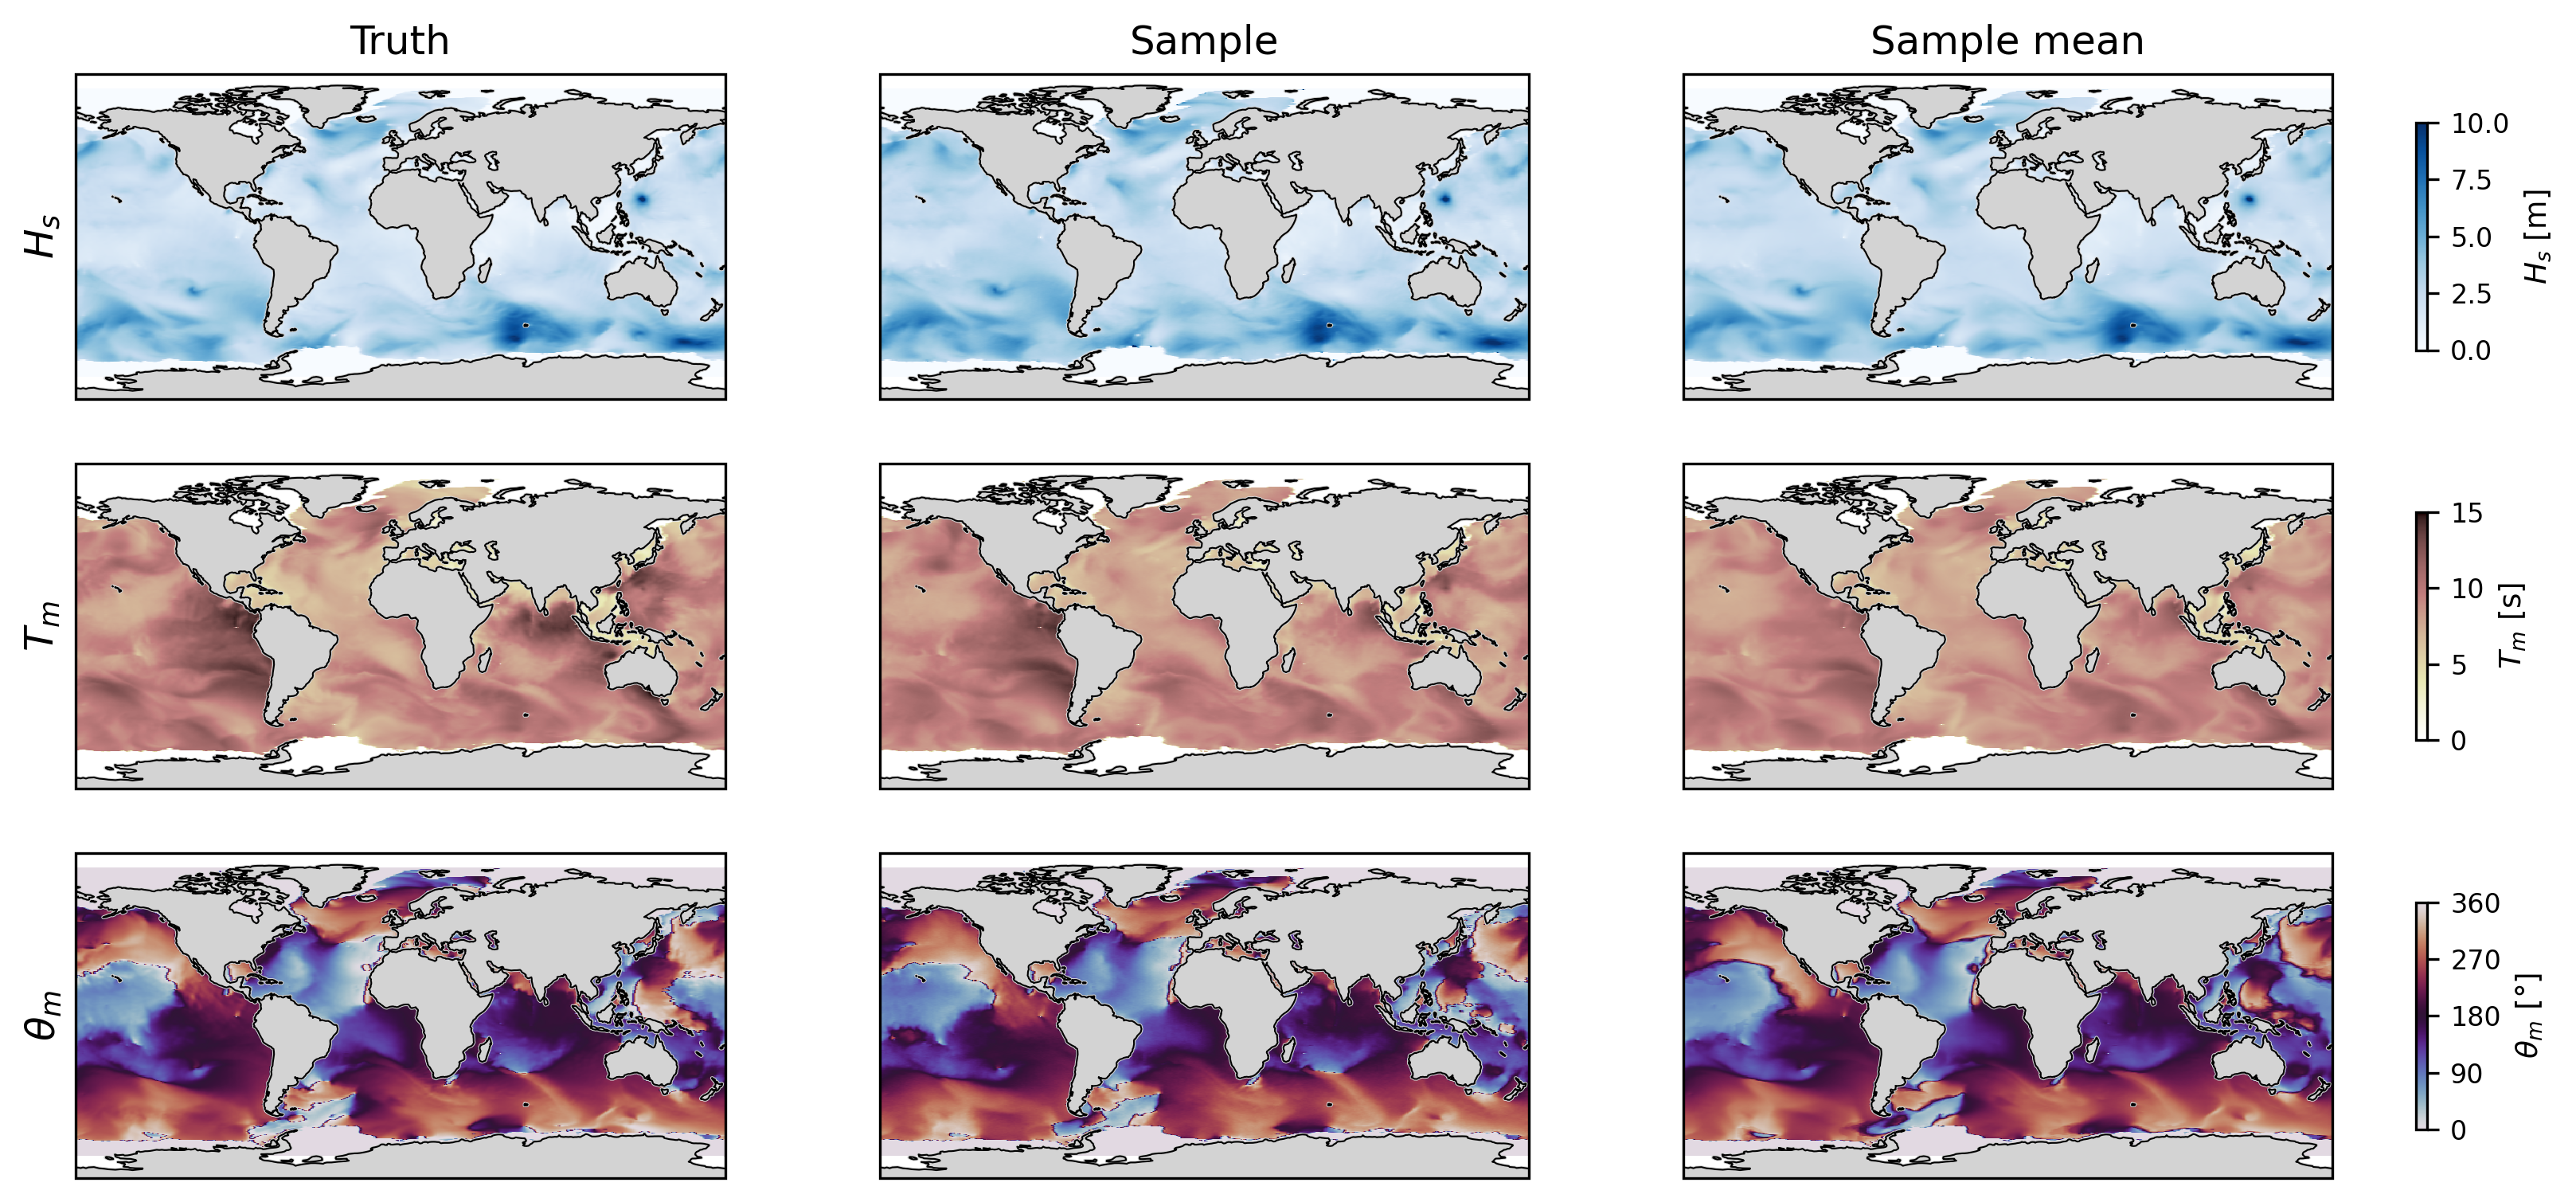

In [13]:
import cartopy.feature as cfeature
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(3, 3, figsize=(15, 6), subplot_kw={'projection': proj}, dpi=300)

fields = [
    ('hs_truth',  'hs_sample',  'hs_mean',  'Blues',    0,  10,  '$H_s$',      '$H_s$ [m]',      None),
    ('tp_truth',  'tp_sample',  'tp_mean',  'pink_r',   0,  15,  '$T_m$',      '$T_m$ [s]',      None),
    ('dir_truth', 'dir_sample', 'dir_mean', 'twilight', 0, 360,  r'$\theta_m$', r'$\theta_m$ [°]', [0, 90, 180, 270, 360]),
]
col_labels = ['Truth', 'Sample', 'Sample mean']

row_ims = []
for i, (var_t, var_s, var_m, cmap, vmin, vmax, row_label, cbar_label, ticks) in enumerate(fields):
    col_data = [ds[var_t].values, ds[var_s].values, ds[var_m].values]
    for j, (data, col_label) in enumerate(zip(col_data, col_labels)):
        ax = axes[i, j]
        im = ax.pcolormesh(lon_deg, lat_deg, data,
                           transform=proj, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.add_feature(cfeature.LAND, color='lightgray', zorder=1)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
        ax.set_global()
        if i == 0:
            ax.set_title(col_label, fontsize=12)
        if j == 0:
            ax.text(-0.08, 0.5, row_label, transform=ax.transAxes,
                    fontsize=12, va='center', rotation=90)
    row_ims.append((im, cbar_label, ticks))

# One vertical colorbar per row, placed to the right
for i, (im, cbar_label, ticks) in enumerate(row_ims):
    cb = fig.colorbar(im, ax=axes[i, :].tolist(), orientation='vertical',
                      pad=0.03, shrink=0.7, aspect=20)
    cb.set_label(cbar_label, fontsize=9)
    cb.ax.tick_params(labelsize=8)
    if ticks is not None:
        cb.set_ticks(ticks)

plt.savefig(f'figure2_panel_{year}{month:02d}{day:02d}.png', bbox_inches='tight')
plt.show()

In [ ]:
import cartopy.feature as cfeature
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(3, 3, figsize=(15, 6), subplot_kw={'projection': proj}, dpi=300)

fields = [
    ('hs_truth',  'hs_sample',  'hs_mean',  'Blues',    0,  10,  '$H_s$',      '$H_s$ [m]',      None),
    ('tp_truth',  'tp_sample',  'tp_mean',  'pink_r',   0,  15,  '$T_m$',      '$T_m$ [s]',      None),
    ('dir_truth', 'dir_sample', 'dir_mean', 'twilight', 0, 360,  r'$\theta_m$', r'$\theta_m$ [°]', [0, 90, 180, 270, 360]),
]
col_labels = ['Truth', 'Sample', 'Sample mean']

row_ims = []
for i, (var_t, var_s, var_m, cmap, vmin, vmax, row_label, cbar_label, ticks) in enumerate(fields):
    col_data = [ds[var_t].values, ds[var_s].values, ds[var_m].values]
    for j, (data, col_label) in enumerate(zip(col_data, col_labels)):
        ax = axes[i, j]
        im = ax.pcolormesh(lon_deg, lat_deg, data,
                           transform=proj, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.add_feature(cfeature.LAND, color='lightgray', zorder=1)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
        ax.set_global()
        if i == 0:
            ax.set_title(col_label, fontsize=12)
        if j == 0:
            ax.text(-0.08, 0.5, row_label, transform=ax.transAxes,
                    fontsize=12, va='center', rotation=90)
    row_ims.append((im, cbar_label, ticks))

# One vertical colorbar per row, placed to the right
for i, (im, cbar_label, ticks) in enumerate(row_ims):
    cb = fig.colorbar(im, ax=axes[i, :].tolist(), orientation='vertical',
                      pad=0.03, shrink=0.7, aspect=20)
    cb.set_label(cbar_label, fontsize=9)
    cb.ax.tick_params(labelsize=8)
    if ticks is not None:
        cb.set_ticks(ticks)

plt.savefig(f'figure2_panel_{year}{month:02d}{day:02d}.png', bbox_inches='tight')
plt.show()

### OPTION 2

### OPTION 3

In [20]:
# Model
OPTION = 3
case = ''
epoch = 4

# Time 
year = 2004
month = 9
index = 64
day = int(index / 8 + 2)

path = f'./temp/OPTION{OPTION}{case}_sigma100_epoch{epoch}_{year}{month:02d}/'
print(f'Reading from {path} snapshot {year}-{month:02d}-{day:02d}...')
x_truth = np.load(f'{path}truth_{index}.npy')
x_mean = np.load(f'{path}mean_{index}.npy')
x_sample = np.load(f'{path}sample_{index}.npy')
x_std = np.load(f'{path}std_{index}.npy')
ds = add_lat_lon (np.concatenate((x_truth[-1:], x_mean[-1:], x_sample[-1:], x_std[-1:]), axis=0), 
                  ('ci_truth', 'ci_mean', 'ci_sample', 'ci_std'))

Reading from ./temp/OPTION3_sigma100_epoch4_200409/ snapshot 2004-09-10...


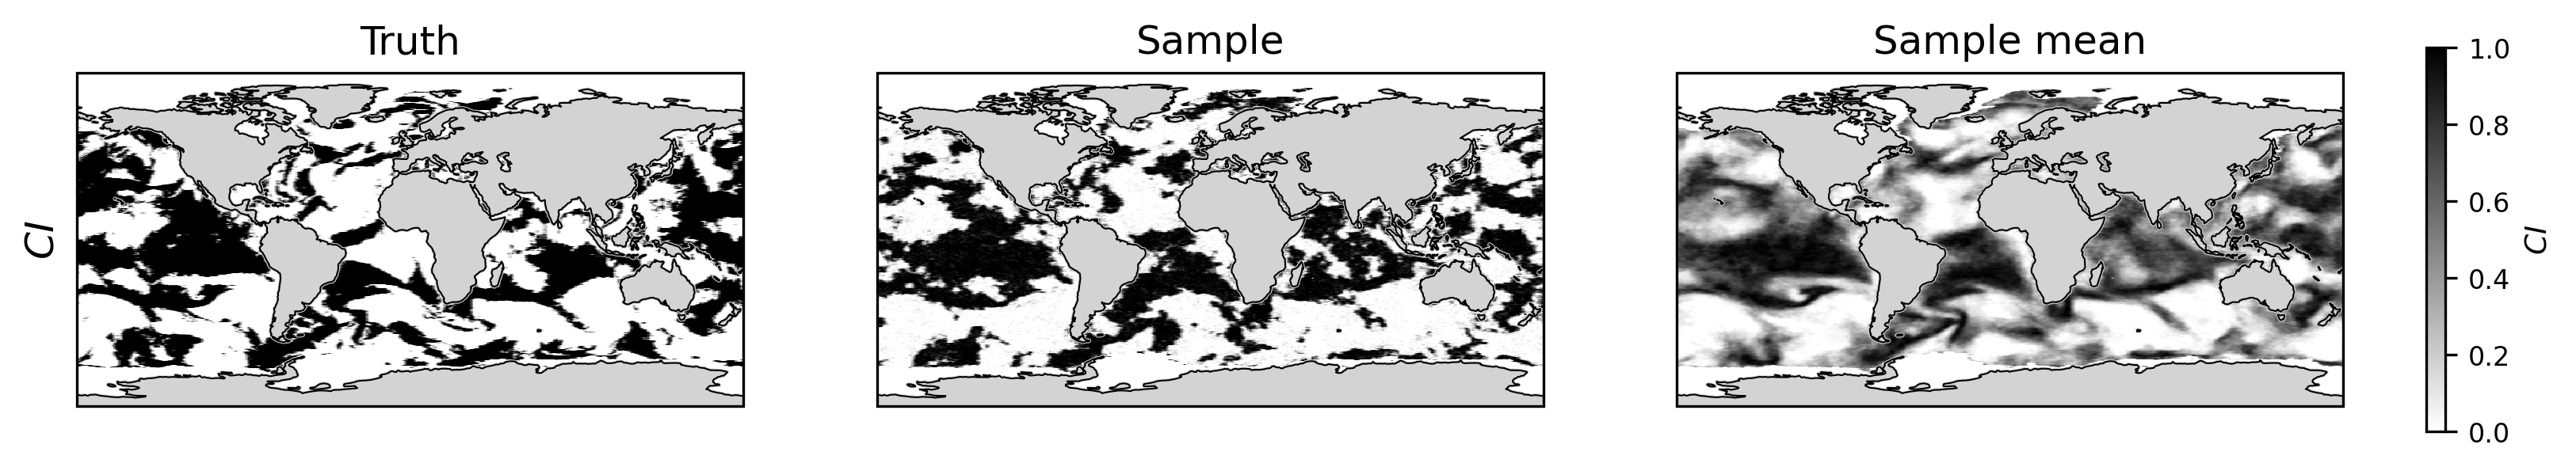

In [22]:
import cartopy.feature as cfeature
proj = ccrs.PlateCarree()

fields = [
    ('ci_truth',  'ci_sample', 'ci_mean',   'binary',    0,  1,  '$CI$',  '$CI$',  None),
]
col_labels = ['Truth', 'Sample', 'Sample mean']

n_rows = len(fields)
fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 3),
                         subplot_kw={'projection': proj}, dpi=300,
                         squeeze=False)  # always 2D axes array

row_ims = []
for i, (var_t, var_s, var_m, cmap, vmin, vmax, row_label, cbar_label, ticks) in enumerate(fields):
    col_data = [ds[var_t].values, ds[var_s].values, ds[var_m].values]
    for j, (data, col_label) in enumerate(zip(col_data, col_labels)):
        ax = axes[i, j]
        im = ax.pcolormesh(lon_deg, lat_deg, data,
                           transform=proj, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.add_feature(cfeature.LAND, color='lightgray', zorder=1)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
        ax.set_global()
        if i == 0:
            ax.set_title(col_label, fontsize=12)
        if j == 0:
            ax.text(-0.08, 0.5, row_label, transform=ax.transAxes,
                    fontsize=12, va='center', rotation=90)
    row_ims.append((im, cbar_label, ticks))

for i, (im, cbar_label, ticks) in enumerate(row_ims):
    cb = fig.colorbar(im, ax=axes[i, :].tolist(), orientation='vertical',
                      pad=0.03, shrink=0.7, aspect=20)
    cb.set_label(cbar_label, fontsize=9)
    cb.ax.tick_params(labelsize=8)
    if ticks is not None:
        cb.set_ticks(ticks)

plt.savefig(f'ci_{year}{month:02d}{day:02d}.png', bbox_inches='tight')
plt.show()